In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import string

## Data Preparation

In [16]:
# Load the dataset and only load the select column as spam and text 
mail = pd.read_csv('PGR210_NLP_data1.csv',usecols=['spam','text'])
print(mail.head())

   spam                                               text
0     0  Go until jurong point, crazy.. Available only ...
1     0                      Ok lar... Joking wif u oni...
2     1  Free entry in 2 a wkly comp to win FA Cup fina...
3     0  U dun say so early hor... U c already then say...
4     0  Nah I don't think he goes to usf, he lives aro...


#### Data exploration

In [17]:
# Basic exploration
print(mail.info())  # Understand mail types and nulls
# Null Values 
print(f'Null Values in Train Dataset is:\n{mail.isnull().sum().sum()}')

# Add the length of each text and eheck legth
mail['length'] = mail['text'].apply(len)
print('Checkc the length info:\n',mail['length'].describe())

# Count the frequency of top 5 mail.
print(mail['text'].value_counts().rename_axis(['text']).reset_index(name='counts').head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4837 entries, 0 to 4836
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   spam    4837 non-null   int64 
 1   text    4837 non-null   object
dtypes: int64(1), object(1)
memory usage: 75.7+ KB
None
Null Values in Train Dataset is:
0
Checkc the length info:
 count     4837.000000
mean        93.505892
std        503.762157
min          2.000000
25%         36.000000
50%         61.000000
75%        121.000000
max      28174.000000
Name: length, dtype: float64
                                                text  counts
0                             Sorry, I'll call later      23
1                                              Ok...       9
2  I cant pick the phone right now. Pls send a me...       9
3                                                 Ok       4
4  Your opinion about me? 1. Over 2. Jada 3. Kusr...       4


No of spam mail :  638
No of nonspam mail :  4199


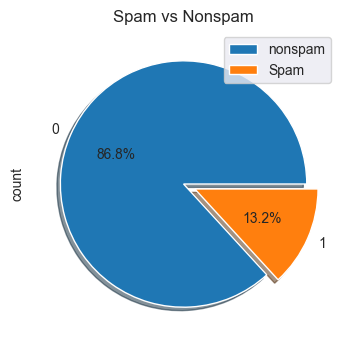

In [18]:
#Visulaze the spam and nonspam 
spam_mail = mail[mail["spam"] == 1]["text"]
nonspam_mail = mail[mail["spam"] == 0]["text"]
print("No of spam mail : ",len(spam_mail))
print("No of nonspam mail : ",len(nonspam_mail))

mail["spam"].value_counts().plot(kind = 'pie',explode=[0, 0.1],figsize=(5, 4),autopct='%1.1f%%',shadow=True)
plt.title("Spam vs Nonspam")
plt.legend(["nonspam", "Spam"])
plt.show()

## Text preprocessing

In [19]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer,PorterStemmer
import string
import re

# Download required NLTK mail_spam
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amundlarsen/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/amundlarsen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/amundlarsen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [20]:
# Define stop words
stop_words = set(stopwords.words('english'))

# Initialize stemmer and lemmatizer
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

# Function to apply text processing on a field in the dataframe
def preprocess_text(text):
    # Define the stop words
    stop_words = stopwords.words('english')  
    # Convert the string to lowercase
    text = text.lower() 
    # Remove extra white spaces
    text = re.sub(r'\s+', ' ', text)  
    # Remove special characters
    text = re.sub(r'[^\w\s]', '', text)
    #Translation to remove punctuation and digits
    text = text.translate(str.maketrans('', '', string.punctuation + string.digits))
    # Split the string into words
    words = text.split()
    # Remove stop words
    words = [word for word in words if word not in stop_words]  
    # Calling Function 
    #words = mail['text'].apply(chat_conversion)
    # Stemming
    words = [stemmer.stem(word) for word in words]
    # Lemmatizing
    words = [lemmatizer.lemmatize(word) for word in words]
    # Join the words back into a string
    return ' '.join(words)

# Apply preprocessing to the entire Text column 
mail['processed_text'] = mail['text'].apply(preprocess_text)

mail.head()

,spam,text,length,processed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,free entri wkli comp win fa cup final tkt st m...
3,0,U dun say so early hor... U c already then say...,49,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,nah dont think goe usf live around though


### TF and TF-IDF representation for dataset

In [21]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# TF Representation of the description field
tf_vectorizer = CountVectorizer(max_features=500)
tf_matrix = tf_vectorizer.fit_transform(mail['processed_text'])
tf_features = tf_vectorizer.get_feature_names_out()

# Add TF representation to the DataFrame
mail['tf'] = [
    {tf_features[i]: count for i, count in zip(row.indices, row.data)}
    for row in tf_matrix
]

# TF-IDF Representation of the description fields
tfidf_vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf_vectorizer.fit_transform(mail['processed_text'])
tfidf_features = tfidf_vectorizer.get_feature_names_out()

# Add TF-IDF representation to the DataFrame
mail['tf-idf'] = [
    {tfidf_features[i]: score for i, score in zip(row.indices, row.data)}
    for row in tfidf_matrix
]

print("TF Shape:", tf_features.shape)
print("TF-IDF Shape:", tfidf_features.shape)

# Display TF and TF-IDF columns
mail[['tf', 'tf-idf']]

TF Shape: (500,)
TF-IDF Shape: (500,)


,tf,tf-idf
0,"{'go': 1, 'point': 1, 'great': 1, 'world': 1, ...","{'go': 0.2908115108766743, 'point': 0.48669223..."
1,"{'ok': 1, 'lar': 1, 'wif': 1}","{'ok': 0.41675687162332653, 'lar': 0.628468141..."
2,"{'free': 1, 'entri': 2, 'win': 1, 'final': 1, ...","{'free': 0.20450308379338086, 'entri': 0.62997..."
3,"{'dun': 1, 'say': 2, 'earli': 1, 'alreadi': 1}","{'dun': 0.4128329971667169, 'say': 0.699712764..."
4,"{'dont': 1, 'think': 1, 'goe': 1, 'live': 1, '...","{'dont': 0.3030758494870307, 'think': 0.338962..."
...,...,...
4832,"{'per': 1, 'prize': 1, 'claim': 1, 'call': 1, ...","{'per': 0.31665915073181156, 'prize': 0.292174..."
4833,"{'go': 1, 'home': 1}","{'go': 0.618623051440709, 'home': 0.7856879280..."
4834,{},{}
4835,"{'free': 1, 'week': 1, 'id': 1, 'like': 1, 'ne...","{'free': 0.26484042938129687, 'week': 0.305972..."


#### Visulize Top words from TF and TFIDF representation

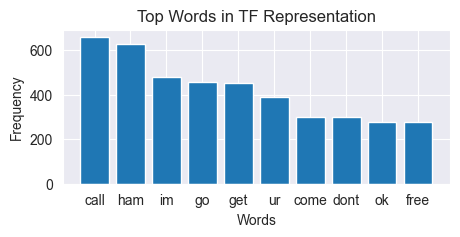

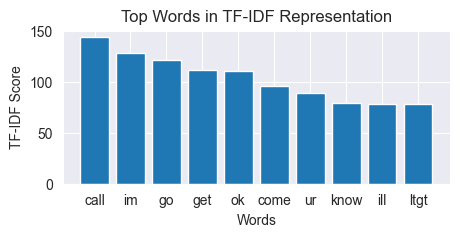

In [22]:
# Function to get top words from TF representation
def get_top_words_tf(tf_column, top_n=10):
    word_counts = {}
    for tf_dict in tf_column:
        for word, count in tf_dict.items():
            if word in word_counts:
                word_counts[word] += count
            else:
                word_counts[word] = count
    sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]

# Function to get top words from TF-IDF representation
def get_top_words_tfidf(tfidf_column, top_n=10):
    word_scores = {}
    for tfidf_dict in tfidf_column:
        for word, score in tfidf_dict.items():
            if word in word_scores:
                word_scores[word] += score
            else:
                word_scores[word] = score
    sorted_words = sorted(word_scores.items(), key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]

# Get top words from TF and TF-IDF representations
top_words_tf = get_top_words_tf(mail['tf'])
top_words_tfidf = get_top_words_tfidf(mail['tf-idf'])

# Plotting the top words for TF representation
plt.figure(figsize=(5, 2))
plt.bar([word for word, count in top_words_tf], [count for word, count in top_words_tf])
plt.title('Top Words in TF Representation')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.show()

# Plotting the top words for TF-IDF representation
plt.figure(figsize=(5, 2))
plt.bar([word for word, score in top_words_tfidf], [score for word, score in top_words_tfidf])
plt.title('Top Words in TF-IDF Representation')
plt.xlabel('Words')
plt.ylabel('TF-IDF Score')
plt.show()

#### Using TF on Latent Dirichlet Allocation (LDiA) model

In [23]:
from sklearn.decomposition import LatentDirichletAllocation

# Fit LDiA model using TF representation
ldia_tf = LatentDirichletAllocation(n_components=10, random_state=42)
ldia_topics = ldia_tf.fit_transform(tf_matrix)

# Function to display topics
def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx +1 }:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

# Display topics for TF representation
print("LDiA Topics using TF representation:")
display_topics(ldia_tf, tf_vectorizer.get_feature_names_out(), 10)

LDiA Topics using TF representation:
Topic 1:
call claim prize ok award txt tri week cash contact
Topic 2:
ham love ur spam miss dont keep good life im
Topic 3:
ill im think sorri still later work call hey sure
Topic 4:
free text call repli ur stop txt mobil get send
Topic 5:
day know good hope dont great morn let find place
Topic 6:
ltgt back hi pl new plea year plan call today
Topic 7:
go im lor ok got wat take home alreadi need
Topic 8:
one night oh right get much said realli ive tomorrow
Topic 9:
well want like time dont use someth see tell get
Topic 10:
come get way dear name phone messag game hous camera


In [24]:
from sklearn.decomposition import TruncatedSVD

# Fit svd model using TF-IDF representation
svd_tfidf = LatentDirichletAllocation(n_components=10, random_state=42)
svd_topics = svd_tfidf.fit_transform(tfidf_matrix)

# Display top words for each topic
def display_topics_svd(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Topic {topic_idx + 1}:")
        print(" ".join([feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]))

print("Truncated SVD Topics using TF_IDF representation:")
display_topics_svd(svd_tfidf, tfidf_vectorizer.get_feature_names_out(), 10)

Truncated SVD Topics using TF_IDF representation:
Topic 1:
call ok claim prize txt win cash contact mobil custom
Topic 2:
love babe that miss like feel dont good happi keep
Topic 3:
later ill sorri still call work think im sure meet
Topic 4:
ur free stop min repli call text tone readi wat
Topic 5:
know want dont sleep great leav let anyth place day
Topic 6:
ltgt good much plan back mani princess pl year fine
Topic 7:
go take lor alreadi ok home watch im ya need
Topic 8:
oh messag send tomorrow one class phone lol realli didnt
Topic 9:
finish also time well hi use someth da money ye
Topic 10:
dear come ask ok way buy got drive say pick


#### Visual the topic by two algos

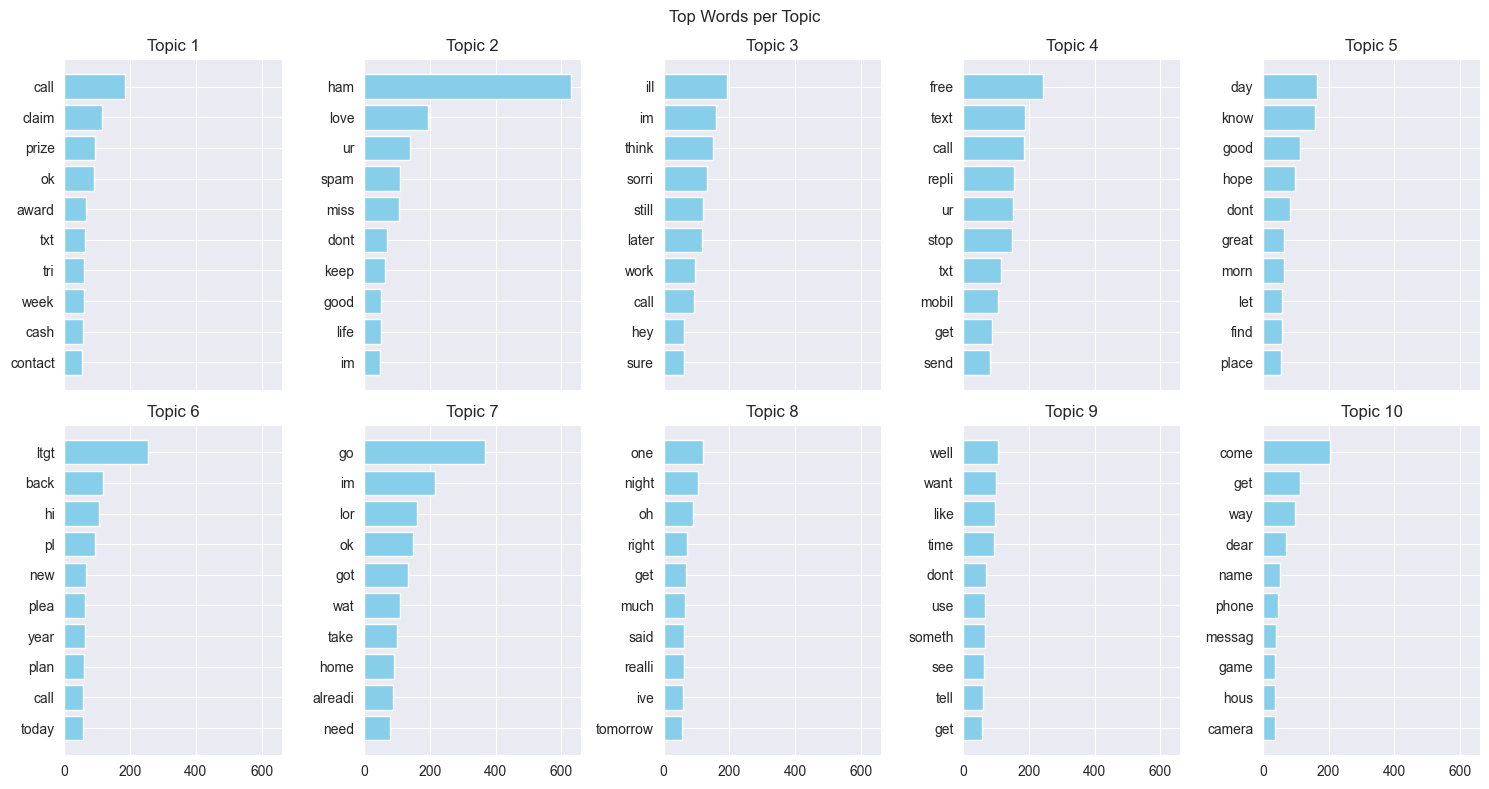

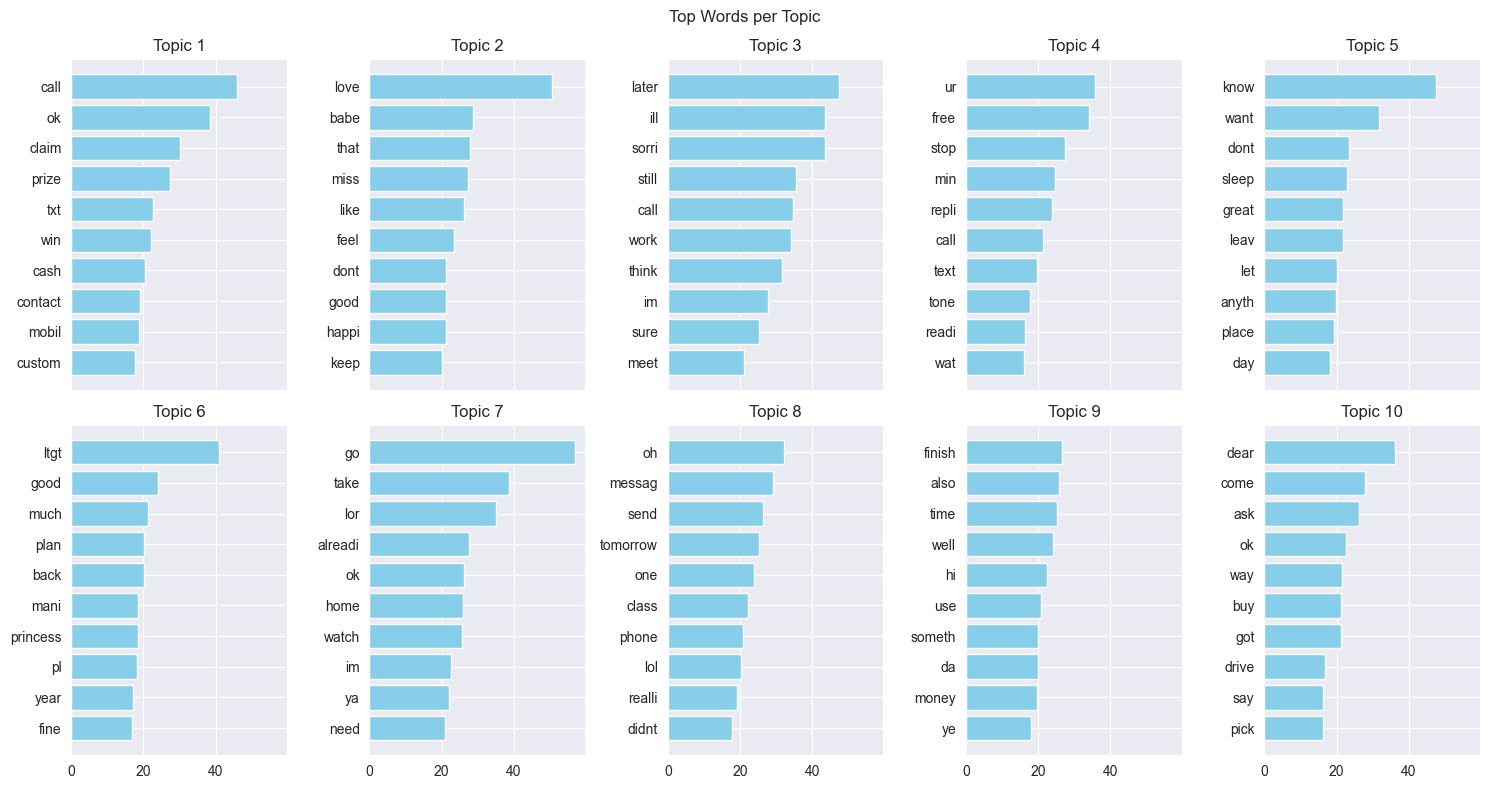

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_top_words(model, feature_names, n_top_words, n_topics=10):
    fig, axes = plt.subplots(2, 5, figsize=(15, 8), sharex=True)
    axes = axes.flatten()
    for topic_idx, topic in enumerate(model.components_[:n_topics]):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        ax.barh(top_features, weights, color='skyblue')
        ax.set_title(f"Topic {topic_idx + 1}")
        ax.invert_yaxis()
    fig.suptitle('Top Words per Topic', fontsize=12)
    plt.tight_layout()
    plt.show()

# Call the function to plot
plot_top_words(ldia_tf, tf_vectorizer.get_feature_names_out(), n_top_words=10)
plot_top_words(svd_tfidf, tfidf_vectorizer.get_feature_names_out(), n_top_words=10)

#### Visual by Heatmap

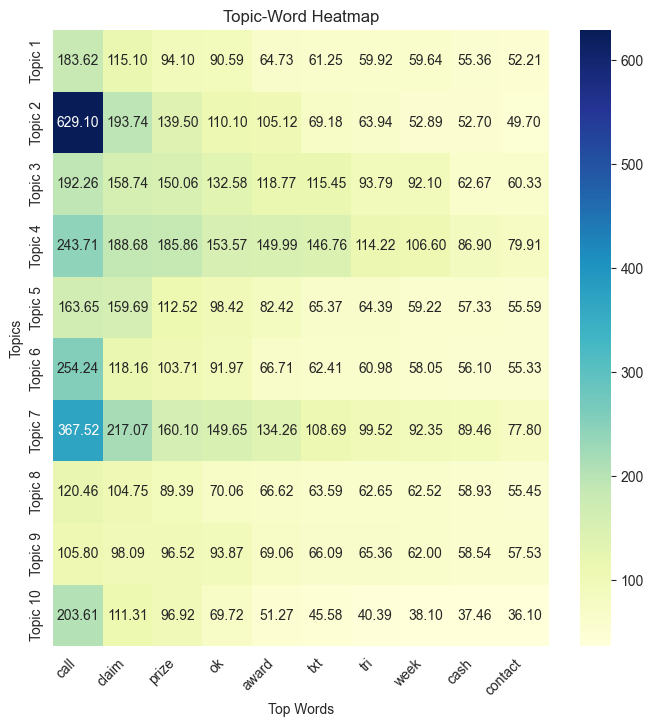

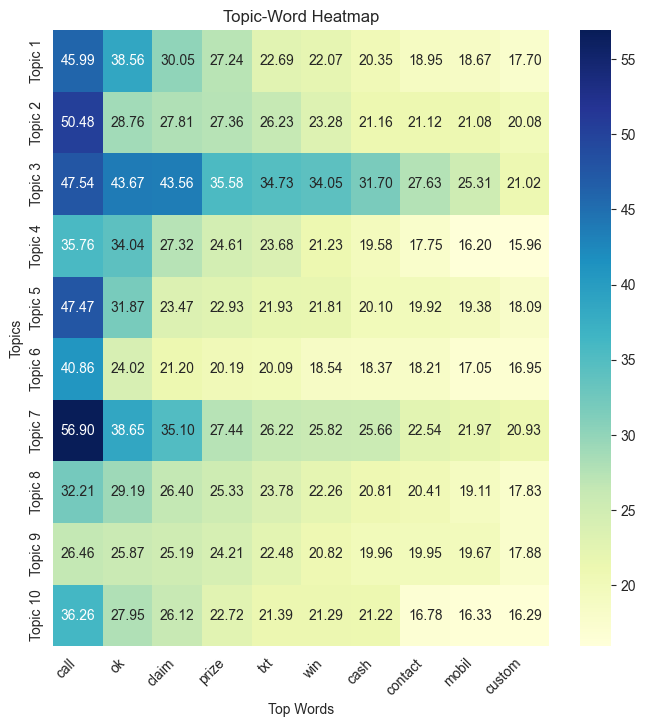

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_topic_heatmap(model, feature_names, n_top_words, n_topics=10):
    # Extract the top words for each topic
    topic_word_weights = []
    top_words = []
    for topic_idx, topic in enumerate(model.components_[:n_topics]):
        top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]
        topic_word_weights.append(weights)
        top_words.append(top_features)
    
    # Convert data to a format suitable for a heatmap
    topic_word_matrix = np.array(topic_word_weights)
    
    # Create the heatmap
    plt.figure(figsize=(8, 8))
    ax = sns.heatmap(
        topic_word_matrix, 
        cmap="YlGnBu", 
        annot=True, 
        fmt=".2f", 
        xticklabels=top_words[0], 
        yticklabels=[f"Topic {i + 1}" for i in range(n_topics)]
    )
    ax.set_title("Topic-Word Heatmap")
    ax.set_xlabel("Top Words")
    ax.set_ylabel("Topics")
    plt.xticks(rotation=45, ha="right")
    plt.show()

# Example usage with LDA and SVD
plot_topic_heatmap(ldia_tf, tf_vectorizer.get_feature_names_out(), n_top_words=10, n_topics=10)
plot_topic_heatmap(svd_tfidf, tfidf_vectorizer.get_feature_names_out(), n_top_words=10, n_topics=10)


In [27]:
''' Compare with the LDA-TF and SVD-TF-IDF's performance'''
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Ensure both LDA-TF and SVD-TFIDF features are derived from the same dataset
X_lida_tf = ldia_topics  # Topic distributions from LDA with TF
X_svd_tfidf = svd_topics    # Reduced features from SVD with TF-IDF
y = mail['spam']            # Labels: spam or not spam

# Split the data into training and testing sets once
X_tf_train, X_tf_test, y_train, y_test = train_test_split(X_lida_tf, y, test_size=0.3, random_state=47)
X_tfidf_train, X_tfidf_test, _, _ = train_test_split(X_svd_tfidf, y, test_size=0.3, random_state=47)

# Train Logistic Regression models for both feature sets
clf_tf = LogisticRegression(random_state=47)
clf_tf.fit(X_tf_train, y_train)
y_pred_tf = clf_tf.predict(X_tf_test)

clf_tfidf = LogisticRegression(random_state=47)
clf_tfidf.fit(X_tfidf_train, y_train)
y_pred_tfidf = clf_tfidf.predict(X_tfidf_test)

# Evaluate performance
accuracy_tf = accuracy_score(y_test, y_pred_tf)
f1_tf = f1_score(y_test, y_pred_tf, average='weighted')

accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf, average='weighted')

# Display results
print("Classification Accuracy using LDA-TF:", accuracy_tf)
print("F1-Score using LDA-TF:", f1_tf)
print("Classification Accuracy using SVD-TFIDF:", accuracy_tfidf)
print("F1-Score using SVD-TFIDF:", f1_tfidf)

Classification Accuracy using LDA-TF: 0.9387052341597796
F1-Score using LDA-TF: 0.9362366390826646
Classification Accuracy using SVD-TFIDF: 0.9194214876033058
F1-Score using SVD-TFIDF: 0.9163932539728025


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.model_selection import cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer

# Baseline: TF-IDF without topic modeling
#tfidf_vectorizer = TfidfVectorizer(max_features=100)
#X_baseline = tfidf_vectorizer.fit_transform(mail['processed_text'])  # Processed text
#y = mail['spam']  # Labels: spam or not spam

# Logistic Regression classifier
clf = LogisticRegression(random_state=47)

# Cross-validation for LDA-TF
cv_accuracy_lda_tf = cross_val_score(clf, X_lida_tf, y, cv=5, scoring='accuracy')
cv_f1_lda_tf = cross_val_score(clf, X_lida_tf, y, cv=5, scoring=make_scorer(f1_score, average='weighted'))

# Cross-validation for SVD-TFIDF
cv_accuracy_svd_tfidf = cross_val_score(clf, X_svd_tfidf, y, cv=5, scoring='accuracy')
cv_f1_svd_tfidf = cross_val_score(clf, X_svd_tfidf, y, cv=5, scoring=make_scorer(f1_score, average='weighted'))

# Cross-validation for baseline TF-IDF
#cv_accuracy_baseline = cross_val_score(clf, X_baseline, y, cv=5, scoring='accuracy')
#cv_f1_baseline = cross_val_score(clf, X_baseline, y, cv=5, scoring=make_scorer(f1_score, average='weighted'))

# Report results
print("LDA-TF Performance:")
print("  Mean Accuracy (CV):", cv_accuracy_lda_tf.mean())
print("  Mean F1-Score (CV):", cv_f1_lda_tf.mean())

print("\nSVD-TFIDF Performance:")
print("  Mean Accuracy (CV):", cv_accuracy_svd_tfidf.mean())
print("  Mean F1-Score (CV):", cv_f1_svd_tfidf.mean())

#print("\nBaseline (TF-IDF) Performance:")
#print("  Mean Accuracy (CV):", cv_accuracy_baseline.mean())
#print("  Mean F1-Score (CV):", cv_f1_baseline.mean())

LDA-TF Performance:
  Mean Accuracy (CV): 0.9394260599793174
  Mean F1-Score (CV): 0.9364066904211026

SVD-TFIDF Performance:
  Mean Accuracy (CV): 0.9185416257147008
  Mean F1-Score (CV): 0.9145807423225486
